<a href="https://colab.research.google.com/github/MIL-Project2/DR-DT/blob/main/Occupancy_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Set your user info (Git is already installed!)
!git config --global user.email "jwas0006@student.monash.edu"
!git config --global user.name "MIL-Project2"

# 2. Clone your repo (if you haven't already)
!git clone https://github.com/MIL-Project2/DR-DT.git
%cd DR-DT

# 3. Make your changes or add new files...

# 4. Push back to GitHub
!git add .
!git commit -m "Updated from Colab"

# 5. Push using your Personal Access Token (paste it when prompted for a password)
!git push

Cloning into 'DR-DT'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 24 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 902.07 KiB | 10.49 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/DR-DT/DR-DT
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [3]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

print("All libraries imported successfully.")

All libraries imported successfully.


In [4]:
df = pd.read_csv('Occupancy-Prediction_Generated_Ver_1.0.csv', delimiter=';')

In [5]:
# ── Missing Values, Data Types & Duplicates ──────────────────────────────────
print("=== DATA AUDIT REPORT ===")
column_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Values': df.isnull().sum(),
    'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
display(column_info)
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nStatistical Summary:")
display(df.describe().round(2))

=== DATA AUDIT REPORT ===


,Data Type,Non-Null Count,Missing Values,Missing (%)
"deviceid,floorspaceid,headcount,timestamp,temperature,humidity,co2,hour,day_of_week,occupancy_lag_5min,occupancy_lag_10min,occupancy_lag_15min,occupancy_rolling_15min,co2_rolling_15min,temperature_rolling_15min",object,1000,0,0.0



Duplicate Rows: 0

Statistical Summary:


,"deviceid,floorspaceid,headcount,timestamp,temperature,humidity,co2,hour,day_of_week,occupancy_lag_5min,occupancy_lag_10min,occupancy_lag_15min,occupancy_rolling_15min,co2_rolling_15min,temperature_rolling_15min"
count,1000
unique,1000
top,"56923747,9f902aab,0,1/11/26 09:45,18.34,65.15,..."
freq,1


## **Exploratory Data Analysis (EDA)**

This section consolidates and extends the EDA. The analysis is structured around four research questions:

- **Q1:** What is the distribution of the target variable “actual_occupancy"?
- **Q2:** Which numerical features are most strongly correlated with “actual_occupancy”?


KeyError: 'headcount'

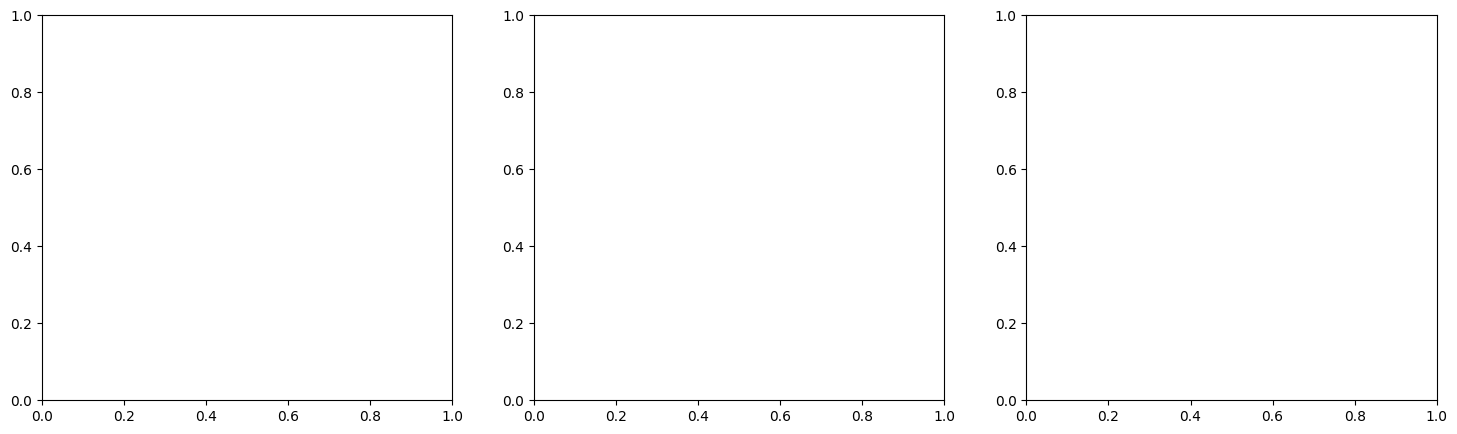

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
sns.histplot(df['headcount'], kde=True, ax=axes[0], color='tab:orange', edgecolor='white')
axes[0].set_title('Distribution of people_count')
axes[0].set_xlabel('headcount'); axes[0].set_ylabel('Count')

# Box plot — outlier check
sns.boxplot(y=df['headcount'], ax=axes[1], color='tab:orange', width=0.4,
            flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
axes[1].set_title('Box Plot — Outlier Check')
axes[1].set_ylabel('headcount')

# Summary statistics panel
desc = df['people_count'].describe()
lines = [f"Count  : {desc['count']:.0f}",
         f"Mean   : {desc['mean']:.2f}",
         f"Std    : {desc['std']:.2f}",
         f"Min    : {desc['min']:.2f}",
         f"25%    : {desc['25%']:.2f}",
         f"Median : {desc['50%']:.2f}",
         f"75%    : {desc['75%']:.2f}",
         f"Max    : {desc['max']:.2f}",
         f"Skew   : {df['headcount'].skew():.4f}",
         f"Kurtosis: {df['headcount'].kurtosis():.4f}"]
axes[2].axis('off')
axes[2].text(0.08, 0.5, '\n'.join(lines), transform=axes[2].transAxes,
             fontsize=11, verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow', alpha=0.9))
axes[2].set_title('Summary Statistics')

plt.suptitle('Target Variable Analysis: headcount', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

print(f"Skewness : {df['headcount'].skew():.4f}  (|skew| < 0.5 = approx. normal)")
print(f"Kurtosis : {df['headcount'].kurtosis():.4f}")
q1, q3 = df['headcount'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df['headcount'] < q1 - 1.5*iqr) | (df['headcount'] > q3 + 1.5*iqr)]
print(f"IQR-based outliers : {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")